# 태양풍 속도 예측

과거 120시간(20시점, 6시간 간격)의 SDO/AIA 193Å·211Å 영상과 태양풍 속도로
이후 6~72시간의 태양풍 속도 12개를 예측한다.

### 접근

- 절대 속도 대신 **마지막 관측값 대비 잔차**를 학습한다.
- 영상에서 **코로나홀 면적**을 격자로 집계해 저차원 물리 피처로 사용한다.
  코로나홀은 고속 태양풍의 근원이며, 소수의 면적 피처만으로도 태양풍 변동의 상당 부분이
  설명된다는 보고가 있다 (Collin et al. 2025, Space Weather).
- 태양풍 전달 시간 τ = 1AU / v 를 이용해 horizon 별로 근원 시각을 역산하고,
  그 시점의 중앙자오선 코로나홀 면적을 **탄도 정렬 피처**로 넣는다.
- 시드와 구성을 달리한 모델을 앙상블하고, horizon 별 가중치는 validation 을
  두 구간으로 나눠 교차검증한 뒤 균등평균보다 나을 때만 채택한다.

평가지표는 horizon 별 RMSE 의 평균이며, 손실함수도 동일한 형태로 맞춘다.

## 1. 설정

In [1]:
from pathlib import Path
import gc, json, math, os, random, shutil, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 777
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_ROOT_CANDIDATES = [
    Path(os.getenv("SW_DATA_ROOT", "")) if os.getenv("SW_DATA_ROOT") else None,
    Path("public_dataset/competition_dataset_6h"),
    Path("/home/jovyan/public_dataset/competition_dataset_6h"),
    Path("public/public_dataset/competition_dataset_6h"),
    Path("/home/jovyan/public/public_dataset/competition_dataset_6h"),
    Path("dataset"), Path("/home/jovyan/dataset"),
]
DATA_ROOT = None
for candidate in DATA_ROOT_CANDIDATES:
    if candidate is not None and (candidate / "train/inputs.csv").exists():
        DATA_ROOT = candidate
        break
if DATA_ROOT is None:
    raise FileNotFoundError("데이터 경로 없음: "
                            + ", ".join(str(c) for c in DATA_ROOT_CANDIDATES if c))

WORK_DIR = Path("work")
CACHE_ROOT = WORK_DIR / "cache"
OUTPUT_DIR = WORK_DIR / "outputs"
SUBMISSION_DIR = Path("submission")
for directory in (CACHE_ROOT, OUTPUT_DIR, SUBMISSION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 128
CHANNELS = ("193", "211")
BATCH_SIZE = 64
EPOCHS = 80
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-3
GRAD_CLIP = 1.0
SCHEDULER_PATIENCE = 4
EARLY_STOP_PATIENCE = 12
NUM_WORKERS = 4
LOSS_EPSILON = 1e-8
LOSS_SCALE = 100.0
EMA_DECAY = 0.999

# 코로나홀 추출
CH_MAX_SIDE = 512          # 원본 해상도 상한
CH_GRID = (3, 5)           # (위도, 경도) 구간 수
CH_PERCENTILES = (4.0, 10.0, 20.0)
DISK_MARGIN = 0.92         # 림 부근 배경 혼입 방지
TRANSIT_SPEEDS = (300.0, 400.0, 500.0, 650.0, 800.0)
AU_KM = 1.496e8

ENSEMBLE_MEMBERS = [
    {"seed": 777, "use_cnn": False, "ch_dropout": 0.4},
    {"seed": 778, "use_cnn": False, "ch_dropout": 0.4},
    {"seed": 779, "use_cnn": False, "ch_dropout": 0.5},
    {"seed": 780, "use_cnn": False, "ch_dropout": 0.3},
    {"seed": 781, "use_cnn": False, "ch_dropout": 0.4},
    {"seed": 782, "use_cnn": True,  "ch_dropout": 0.4},
    {"seed": 783, "use_cnn": True,  "ch_dropout": 0.4},
]

USE_BALLISTIC = True
DROPOUT = 0.4
HORIZON_EMBED = 8
AUGMENT = True
AUG_BRIGHTNESS = 0.10
AUG_SHIFT_PIXELS = 6
AUG_NOISE_STD = 0.02
AUG_ERASE_PROB = 0.3
AUG_CH_NOISE = 0.05

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

ANY_CNN = any(member["use_cnn"] for member in ENSEMBLE_MEMBERS)
print("PyTorch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("data:", DATA_ROOT.resolve())
print(f"ensemble members: {len(ENSEMBLE_MEMBERS)} "
      f"(cnn {sum(m['use_cnn'] for m in ENSEMBLE_MEMBERS)})")

PyTorch: 2.5.1+cu124 | device: cuda
GPU: NVIDIA A100-SXM4-40GB
data: /home/jovyan/public_dataset/competition_dataset_6h
ensemble members: 7 (cnn 2)


## 2. 데이터 로드

태양풍 관측값에는 결손 구간이 존재할 수 있으므로 forward fill → backward fill → 전역 중앙값
순으로 채우고, 결측 여부를 별도 플래그로 모델에 함께 전달한다.

In [2]:
IMAGE_COLUMNS = [f"image_{i:02d}" for i in range(20)]
WIND_COLUMNS = [f"wind_{i:02d}" for i in range(20)]
TARGET_COLUMNS = [f"target_{i:02d}" for i in range(12)]
HORIZONS = np.arange(1, 13) * 6

train_inputs = pd.read_csv(DATA_ROOT / "train/inputs.csv")
train_targets_frame = pd.read_csv(DATA_ROOT / "train/targets.csv")
val_inputs = pd.read_csv(DATA_ROOT / "validation/inputs.csv")
val_targets_frame = pd.read_csv(DATA_ROOT / "validation/targets.csv")
test_inputs = pd.read_csv(DATA_ROOT / "test/inputs.csv")
test_ids = pd.read_csv(DATA_ROOT / "test/test_ids.csv")

assert train_inputs.sample_id.tolist() == train_targets_frame.sample_id.tolist()
assert val_inputs.sample_id.tolist() == val_targets_frame.sample_id.tolist()
assert test_inputs.sample_id.tolist() == test_ids.sample_id.tolist()
assert set(train_inputs.sample_id).isdisjoint(val_inputs.sample_id)
assert set(train_inputs.sample_id).isdisjoint(test_inputs.sample_id)
assert set(val_inputs.sample_id).isdisjoint(test_inputs.sample_id)
assert not any(c.startswith("target_") for c in test_inputs.columns)


def forward_fill_rows(values):
    valid = np.isfinite(values)
    positions = np.where(valid, np.arange(values.shape[1])[None, :], 0)
    np.maximum.accumulate(positions, axis=1, out=positions)
    rows = np.arange(values.shape[0])[:, None]
    return np.where(valid.any(axis=1, keepdims=True), values[rows, positions], values)


def fill_wind(frame, fallback):
    values = frame[WIND_COLUMNS].to_numpy(np.float32)
    valid = np.isfinite(values).astype(np.float32)
    filled = forward_fill_rows(values)
    filled = forward_fill_rows(filled[:, ::-1])[:, ::-1]
    filled = np.where(np.isfinite(filled), filled, fallback)
    return np.ascontiguousarray(filled), np.ascontiguousarray(valid)


WIND_FALLBACK = float(np.nanmedian(train_inputs[WIND_COLUMNS].to_numpy(np.float32)))
train_wind, train_wind_valid = fill_wind(train_inputs, WIND_FALLBACK)
val_wind, val_wind_valid = fill_wind(val_inputs, WIND_FALLBACK)
test_wind, test_wind_valid = fill_wind(test_inputs, WIND_FALLBACK)
train_targets = train_targets_frame[TARGET_COLUMNS].to_numpy(np.float32)
val_targets = val_targets_frame[TARGET_COLUMNS].to_numpy(np.float32)
assert np.isfinite(train_targets).all() and np.isfinite(val_targets).all()

missing = int((~np.isfinite(train_inputs[WIND_COLUMNS].to_numpy(np.float32))).sum())
print(f"samples: {len(train_inputs)} / {len(val_inputs)} / {len(test_inputs)}")
print(f"train wind missing: {missing}")
print(f"train target mean {train_targets.mean():.1f}, std {train_targets.std():.1f}")

samples: 9607 / 1199 / 3868
train wind missing: 0
train target mean 415.4, std 90.1


## 3. 영상 캐시

슬라이딩 윈도우 구성이라 동일 PNG 가 여러 샘플에 반복 등장한다.
고유 파일 단위로 한 번만 리사이즈해 uint8 memory-map 으로 보관한다.
CNN 브랜치를 쓰는 멤버가 없으면 생략한다.

In [3]:
def unique_filenames(inputs):
    return sorted(pd.unique(inputs[IMAGE_COLUMNS].to_numpy().ravel()).tolist())


def prepare_image_memmap(split, inputs):
    image_root = DATA_ROOT / split
    cache_root = CACHE_ROOT / f"{IMAGE_SIZE}px"
    cache_root.mkdir(parents=True, exist_ok=True)
    array_path = cache_root / f"{split}_images.npy"
    metadata_path = cache_root / f"{split}_metadata.json"
    filenames = unique_filenames(inputs)
    expected = {"image_size": IMAGE_SIZE, "channels": list(CHANNELS), "filenames": filenames}
    shape = (len(filenames), len(CHANNELS), IMAGE_SIZE, IMAGE_SIZE)

    valid = False
    if array_path.exists() and metadata_path.exists():
        try:
            cached = np.load(array_path, mmap_mode="r")
            valid = (json.loads(metadata_path.read_text(encoding="utf-8")) == expected
                     and cached.shape == shape and cached.dtype == np.uint8)
        except (OSError, ValueError, json.JSONDecodeError):
            valid = False

    if not valid:
        array_temp = array_path.with_name(array_path.name + f".partial.{os.getpid()}")
        meta_temp = metadata_path.with_name(metadata_path.name + f".partial.{os.getpid()}")
        resized = np.lib.format.open_memmap(array_temp, mode="w+", dtype=np.uint8, shape=shape)
        for index, name in enumerate(filenames):
            for channel_index, channel in enumerate(CHANNELS):
                with Image.open(image_root / channel / name) as image:
                    resized[index, channel_index] = np.asarray(
                        image.convert("L").resize((IMAGE_SIZE, IMAGE_SIZE),
                                                  Image.Resampling.BILINEAR), dtype=np.uint8)
            if (index + 1) % 2000 == 0 or index + 1 == len(filenames):
                print(f"{split} resize {index + 1}/{len(filenames)}", flush=True)
        resized.flush(); del resized
        meta_temp.write_text(json.dumps(expected, ensure_ascii=False) + "\n", encoding="utf-8")
        array_temp.replace(array_path); meta_temp.replace(metadata_path)

    return np.load(array_path, mmap_mode="r"), {n: i for i, n in enumerate(filenames)}


if ANY_CNN:
    train_image_array, train_image_map = prepare_image_memmap("train", train_inputs)
    val_image_array, val_image_map = prepare_image_memmap("validation", val_inputs)
    test_image_array, test_image_map = prepare_image_memmap("test", test_inputs)
else:
    train_image_array = val_image_array = test_image_array = None
    train_image_map = {n: i for i, n in enumerate(unique_filenames(train_inputs))}
    val_image_map = {n: i for i, n in enumerate(unique_filenames(val_inputs))}
    test_image_map = {n: i for i, n in enumerate(unique_filenames(test_inputs))}
print("image cache ready" if ANY_CNN else "image cache skipped (no cnn member)")

image cache ready


## 4. 코로나홀 면적 추출

원본 PNG 를 순차적으로 읽어 격자별 코로나홀 면적 비율만 계산한다. 영상 자체는 저장하지 않으므로
디스크 사용량이 작고, 128px 로 축소했을 때보다 면적 추정이 안정적이다.

절차는 다음과 같다.

1. 표본 평균 영상에서 태양 원반의 중심과 반지름을 추정한다.
2. 원반 내부 중앙값으로 밝기를 정규화한다. PNG 변환 시 비선형 스케일이 적용됐을 수 있어
   고정 비율 대신 **백분위 기준** 임계를 쓴다.
3. 임계를 하나로 정하지 않고 4 / 10 / 20 % 세 단계를 모두 산출해 밝기 프로파일로 사용한다.
4. 193Å 과 211Å 양쪽에서 어두운 픽셀만 코로나홀로 인정해 필라멘트 오검출을 줄인다.
5. 원반을 (위도 × 경도) 격자로 나눠 셀별 면적 비율을 구한다.

disk: side=512 center=(254.3,256.3) radius=220.5 (86% of frame), pixels 152,687
thresholds (4.0, 10.0, 20.0):
[[0.     0.4083]
 [0.431  0.6364]
 [0.6667 0.7734]]
  test 2000/4115 (400s)
  test 4000/4115 (800s)
  test 4115/4115 (823s)

coronal hole area fraction:
  p=  4.0%  disk 0.0000  central cell 0.0000
  p= 10.0%  disk 0.0665  central cell 0.0949
  p= 20.0%  disk 0.1345  central cell 0.2255


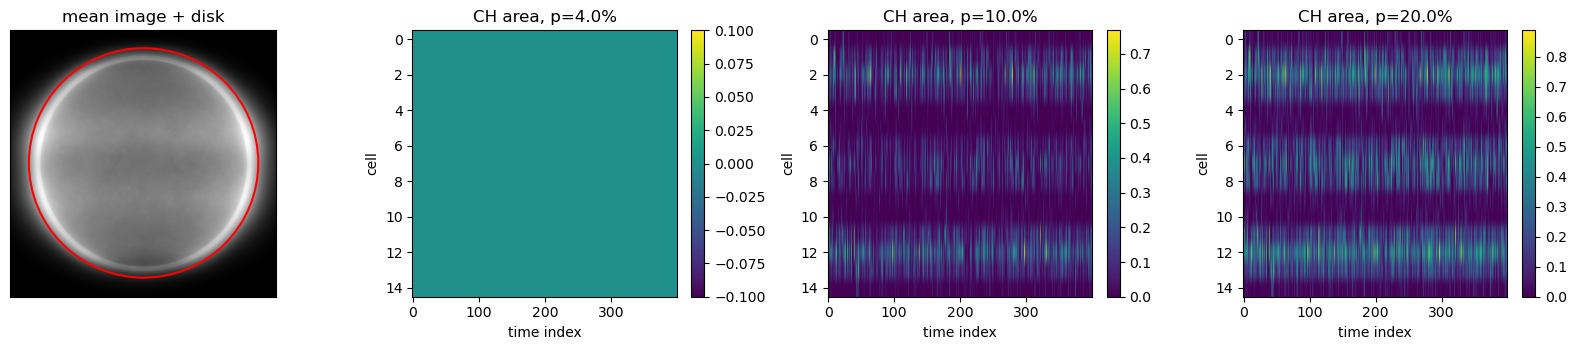

In [5]:
n_lat, n_lon = CH_GRID
N_CELLS = n_lat * n_lon
N_LEVELS = len(CH_PERCENTILES)
CENTRAL_LON = n_lon // 2
EQUATOR_LAT = n_lat // 2
CENTRAL_CELL = EQUATOR_LAT * n_lon + CENTRAL_LON


def load_native(split, name, max_side=CH_MAX_SIDE):
    planes = []
    for channel in CHANNELS:
        with Image.open(DATA_ROOT / split / channel / name) as image:
            image = image.convert("L")
            if max(image.size) > max_side:
                image = image.resize((max_side, max_side), Image.Resampling.BILINEAR)
            planes.append(np.asarray(image, dtype=np.float32))
    return np.stack(planes)


def calibrate(split, filenames, sample_count=300):
    indexes = np.unique(np.linspace(0, len(filenames) - 1, sample_count).astype(int))
    stack = np.stack([load_native(split, filenames[i]) for i in indexes])
    side = stack.shape[-1]

    mean_image = stack.mean(axis=(0, 1))
    mask = mean_image > mean_image.max() * 0.15
    ys, xs = np.nonzero(mask)
    center_y, center_x = float(ys.mean()), float(xs.mean())
    radius = float(np.sqrt(mask.sum() / np.pi)) * DISK_MARGIN

    grid_y, grid_x = np.mgrid[0:side, 0:side].astype(np.float64)
    disk_mask = np.sqrt((grid_y - center_y) ** 2 + (grid_x - center_x) ** 2) <= radius

    lat = np.clip((grid_y - (center_y - radius)) / (2 * radius) * n_lat, 0, n_lat - 1e-6)
    lon = np.clip((grid_x - (center_x - radius)) / (2 * radius) * n_lon, 0, n_lon - 1e-6)
    cell_id = (lat.astype(np.int64) * n_lon + lon.astype(np.int64))[disk_mask]
    onehot = np.zeros((len(cell_id), N_CELLS), dtype=np.float32)
    onehot[np.arange(len(cell_id)), cell_id] = 1.0
    counts = np.maximum(onehot.sum(axis=0), 1.0)

    on_disk = stack[:, :, disk_mask]
    normalized = on_disk / np.maximum(np.median(on_disk, axis=2, keepdims=True), 1e-3)
    per_channel = normalized.transpose(1, 0, 2).reshape(len(CHANNELS), -1)
    thresholds = np.stack([np.percentile(per_channel, p, axis=1)
                           for p in CH_PERCENTILES]).astype(np.float32)

    print(f"disk: side={side} center=({center_y:.1f},{center_x:.1f}) radius={radius:.1f} "
          f"({2 * radius / side:.0%} of frame), pixels {int(disk_mask.sum()):,}")
    print(f"thresholds {CH_PERCENTILES}:\n{np.round(thresholds, 4)}")
    return dict(disk_mask=disk_mask, onehot=onehot, counts=counts,
                thresholds=thresholds, mean_image=mean_image,
                center=(center_y, center_x), radius=radius)


def extract_ch(split, filenames, calibration):
    disk_mask = calibration["disk_mask"]
    onehot, counts = calibration["onehot"], calibration["counts"]
    result = np.zeros((len(filenames), N_LEVELS, N_CELLS), dtype=np.float32)
    started = time.perf_counter()
    for index, name in enumerate(filenames):
        on_disk = load_native(split, name)[:, disk_mask]
        normalized = on_disk / np.maximum(np.median(on_disk, axis=1, keepdims=True), 1e-3)
        for level, threshold in enumerate(calibration["thresholds"]):
            dark = normalized < threshold[:, None]
            coronal = np.logical_and(dark[0], dark[1]).astype(np.float32)
            result[index, level] = (coronal @ onehot) / counts
        if (index + 1) % 2000 == 0 or index + 1 == len(filenames):
            print(f"  {split} {index + 1}/{len(filenames)} "
                  f"({time.perf_counter() - started:.0f}s)", flush=True)
    return result


train_files = unique_filenames(train_inputs)
val_files = unique_filenames(val_inputs)
test_files = unique_filenames(test_inputs)
CALIBRATION = calibrate("train", train_files)


def cached_ch(split, filenames):
    tag = f"{n_lat}x{n_lon}_p{'-'.join(str(p) for p in CH_PERCENTILES)}_m{DISK_MARGIN}"
    path = CACHE_ROOT / f"ch_{split}_{tag}.npy"
    if path.exists():
        grid = np.load(path)
        if grid.shape == (len(filenames), N_LEVELS, N_CELLS):
            return grid
    grid = extract_ch(split, filenames, CALIBRATION)
    np.save(path, grid)
    return grid


train_ch = cached_ch("train", train_files)
val_ch = cached_ch("validation", val_files)
test_ch = cached_ch("test", test_files)

print("\ncoronal hole area fraction:")
for level, percentile in enumerate(CH_PERCENTILES):
    print(f"  p={percentile:5.1f}%  disk {train_ch[:, level].mean():.4f}  "
          f"central cell {train_ch[:, level, CENTRAL_CELL].mean():.4f}")

figure, axes = plt.subplots(1, N_LEVELS + 1, figsize=(4 * (N_LEVELS + 1), 3.6))
axes[0].imshow(CALIBRATION["mean_image"], cmap="gray")
axes[0].add_patch(plt.Circle(CALIBRATION["center"][::-1], CALIBRATION["radius"],
                             fill=False, color="red", linewidth=1.5))
axes[0].set_title("mean image + disk"); axes[0].set_xticks([]); axes[0].set_yticks([])
for level, percentile in enumerate(CH_PERCENTILES):
    image = axes[level + 1].imshow(train_ch[:400, level].T, aspect="auto", cmap="viridis")
    axes[level + 1].set_title(f"CH area, p={percentile}%")
    axes[level + 1].set_xlabel("time index"); axes[level + 1].set_ylabel("cell")
    figure.colorbar(image, ax=axes[level + 1], fraction=0.046)
plt.tight_layout(); plt.show()

## 5. 피처 구성

**탄도 정렬** — horizon $h$ 의 타깃이 발원한 시각은 $T_0 + h - \tau$ 이고 $\tau = \mathrm{1AU}/v$ 이다.
가정 속도 5개에 대해 윈도우 내 실수 인덱스를 구하고, 그 시점의 중앙자오선 코로나홀 면적을
임계 3단계 모두 선형보간해 horizon 당 15개 피처를 만든다.
윈도우를 벗어나는 경우(고속풍 + 장기 horizon)는 양 끝으로 clamp 한다.

정규화 통계는 모두 train split 에서만 산출한다.

In [6]:
def image_index_matrix(inputs, image_map):
    return np.asarray([[image_map[n] for n in row]
                       for row in inputs[IMAGE_COLUMNS].itertuples(index=False, name=None)],
                      dtype=np.int32)


def ballistic_indices():
    table = np.zeros((12, len(TRANSIT_SPEEDS)), dtype=np.float32)
    for horizon_index in range(12):
        lead = (horizon_index + 1) * 6.0
        for speed_index, speed in enumerate(TRANSIT_SPEEDS):
            transit = AU_KM / speed / 3600.0
            table[horizon_index, speed_index] = np.clip(19.0 + (lead - transit) / 6.0, 0.0, 19.0)
    return table


BALLISTIC_INDEX = ballistic_indices()
N_SPEEDS = len(TRANSIT_SPEEDS)
BALLISTIC_DIM = N_SPEEDS * N_LEVELS


def compute_ballistic(ch_grid, indexes):
    central = ch_grid[indexes][:, :, :, CENTRAL_CELL]
    lower = np.floor(BALLISTIC_INDEX).astype(np.int64)
    upper = np.minimum(lower + 1, 19)
    weight = (BALLISTIC_INDEX - lower).astype(np.float32)[..., None]
    interpolated = central[:, lower] * (1.0 - weight) + central[:, upper] * weight
    return interpolated.reshape(len(indexes), 12, BALLISTIC_DIM).astype(np.float32)


def flatten_ch(ch_grid, indexes):
    return ch_grid[indexes].reshape(len(indexes), 20, N_LEVELS * N_CELLS).astype(np.float32)


train_index_matrix = image_index_matrix(train_inputs, train_image_map)
val_index_matrix = image_index_matrix(val_inputs, val_image_map)
test_index_matrix = image_index_matrix(test_inputs, test_image_map)

train_ch_seq = flatten_ch(train_ch, train_index_matrix)
CH_SEQ_DIM = train_ch_seq.shape[2]
CH_SEQ_MEAN = train_ch_seq.reshape(-1, CH_SEQ_DIM).mean(axis=0).astype(np.float32)
CH_SEQ_STD = (train_ch_seq.reshape(-1, CH_SEQ_DIM).std(axis=0) + 1e-8).astype(np.float32)

train_ballistic = compute_ballistic(train_ch, train_index_matrix)
BALLISTIC_MEAN = train_ballistic.reshape(-1, BALLISTIC_DIM).mean(axis=0).astype(np.float32)
BALLISTIC_STD = (train_ballistic.reshape(-1, BALLISTIC_DIM).std(axis=0) + 1e-8).astype(np.float32)

WIND_MEAN = float(train_wind.mean())
WIND_STD = float(train_wind.std() + 1e-6)
DIFF_STD = float(np.diff(train_wind, axis=1, prepend=train_wind[:, :1]).std() + 1e-6)

IMAGE_MEAN = np.array([0.5] * len(CHANNELS), np.float32)
IMAGE_STD = np.array([0.25] * len(CHANNELS), np.float32)
if ANY_CNN:
    total = np.zeros(len(CHANNELS), np.float64)
    total_square = np.zeros(len(CHANNELS), np.float64)
    count = 0
    for start in range(0, len(train_image_array), 256):
        block = np.asarray(train_image_array[start:start + 256], np.float64) / 255.0
        total += block.sum(axis=(0, 2, 3))
        total_square += (block ** 2).sum(axis=(0, 2, 3))
        count += block.shape[0] * block.shape[2] * block.shape[3]
    IMAGE_MEAN = (total / count).astype(np.float32)
    IMAGE_STD = np.sqrt(np.maximum(total_square / count - IMAGE_MEAN ** 2, 1e-12)).astype(np.float32)

# 잔차 통계는 모델 출력단 affine 으로 사용해 초기 스케일을 맞춘다.
train_residual = train_targets - train_wind[:, -1:]
RESIDUAL_MEAN = train_residual.mean(axis=0).astype(np.float32)
RESIDUAL_STD = (train_residual.std(axis=0) + 1e-6).astype(np.float32)
CLIP_LOW = float(train_targets.min() * 0.95)
CLIP_HIGH = float(train_targets.max() * 1.05)

print("ballistic source index (19 = last observation):")
print(pd.DataFrame(BALLISTIC_INDEX, index=[f"{h}h" for h in HORIZONS],
                   columns=[f"v={int(v)}" for v in TRANSIT_SPEEDS]).round(2))
print(f"\nch sequence dim {CH_SEQ_DIM}, ballistic dim {BALLISTIC_DIM}")
print(f"clip range [{CLIP_LOW:.1f}, {CLIP_HIGH:.1f}] km/s")

ballistic source index (19 = last observation):
     v=300  v=400  v=500  v=650  v=800
6h    0.00   2.69   6.15   9.34  11.34
12h   0.00   3.69   7.15  10.34  12.34
18h   0.00   4.69   8.15  11.34  13.34
24h   0.00   5.69   9.15  12.34  14.34
30h   0.91   6.69  10.15  13.34  15.34
36h   1.91   7.69  11.15  14.34  16.34
42h   2.91   8.69  12.15  15.34  17.34
48h   3.91   9.69  13.15  16.34  18.34
54h   4.91  10.69  14.15  17.34  19.00
60h   5.91  11.69  15.15  18.34  19.00
66h   6.91  12.69  16.15  19.00  19.00
72h   7.91  13.69  17.15  19.00  19.00

ch sequence dim 45, ballistic dim 15
clip range [244.1, 865.2] km/s


## 6. Dataset

In [7]:
STAT_NAMES = ["last", "mean4", "mean", "std", "min", "max", "slope", "last_minus_mean4", "range"]
_TIME_CENTERED = np.arange(20, dtype=np.float32) - 9.5
_TIME_DENOM = float((_TIME_CENTERED ** 2).sum())


def build_wind_stats(wind):
    last = wind[:, -1]
    mean4 = wind[:, -4:].mean(axis=1)
    slope = (wind - wind.mean(axis=1, keepdims=True)) @ _TIME_CENTERED / _TIME_DENOM
    return np.stack([last, mean4, wind.mean(axis=1), wind.std(axis=1), wind.min(axis=1),
                     wind.max(axis=1), slope, last - mean4,
                     wind.max(axis=1) - wind.min(axis=1)], axis=1).astype(np.float32)


_stats_raw = build_wind_stats(train_wind)
STATS_MEAN = _stats_raw.mean(axis=0).astype(np.float32)
STATS_STD = (_stats_raw.std(axis=0) + 1e-6).astype(np.float32)
NUM_STATS = len(STAT_NAMES)


class SolarWindDataset(Dataset):
    def __init__(self, image_array, index_matrix, inputs, wind, wind_valid,
                 ch_grid, targets=None, training=False, provide_images=False):
        self.training = training
        self.provide_images = provide_images
        self.image_array = image_array
        self.image_indexes = index_matrix
        self.sample_ids = inputs.sample_id.to_numpy()
        self.last_wind = np.ascontiguousarray(wind[:, -1]).astype(np.float32)
        self.wind_seq = np.stack([(wind - WIND_MEAN) / WIND_STD,
                                  np.diff(wind, axis=1, prepend=wind[:, :1]) / DIFF_STD,
                                  wind_valid], axis=2).astype(np.float32)
        self.wind_stats = ((build_wind_stats(wind) - STATS_MEAN) / STATS_STD).astype(np.float32)
        self.ch_seq = ((flatten_ch(ch_grid, index_matrix) - CH_SEQ_MEAN)
                       / CH_SEQ_STD).astype(np.float32)
        self.ballistic = ((compute_ballistic(ch_grid, index_matrix) - BALLISTIC_MEAN)
                          / BALLISTIC_STD).astype(np.float32)
        self.targets = targets.astype(np.float32) if targets is not None else None
        self.image_mean = IMAGE_MEAN.reshape(1, len(CHANNELS), 1, 1)
        self.image_std = IMAGE_STD.reshape(1, len(CHANNELS), 1, 1)

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, item):
        if self.provide_images:
            images = np.asarray(self.image_array[self.image_indexes[item]], np.float32) / 255.0
            images = ((images - self.image_mean) / self.image_std).astype(np.float32)
        else:
            images = np.zeros((1, 1, 1, 1), dtype=np.float32)

        ch_seq = self.ch_seq[item]
        ballistic = self.ballistic[item]
        if self.training and AUGMENT and AUG_CH_NOISE > 0:
            ch_seq = ch_seq * (1.0 + np.random.normal(
                0, AUG_CH_NOISE, ch_seq.shape)).astype(np.float32)
            ballistic = ballistic * (1.0 + np.random.normal(
                0, AUG_CH_NOISE, ballistic.shape)).astype(np.float32)

        result = {"images": torch.from_numpy(np.ascontiguousarray(images)),
                  "wind_seq": torch.from_numpy(self.wind_seq[item]),
                  "wind_stats": torch.from_numpy(self.wind_stats[item]),
                  "ch_seq": torch.from_numpy(np.ascontiguousarray(ch_seq)),
                  "ballistic": torch.from_numpy(np.ascontiguousarray(ballistic)),
                  "last_wind": torch.tensor(self.last_wind[item]),
                  "sample_id": self.sample_ids[item]}
        if self.targets is not None:
            result["target"] = torch.from_numpy(self.targets[item])
        return result


def seed_worker(worker_id):
    worker_seed = (SEED + worker_id) % (2 ** 32)
    random.seed(worker_seed); np.random.seed(worker_seed)


def make_loader(dataset, shuffle, seed=SEED):
    options = dict(dataset=dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
                   num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
                   worker_init_fn=seed_worker,
                   generator=torch.Generator().manual_seed(seed))
    if NUM_WORKERS > 0:
        options.update(persistent_workers=True, prefetch_factor=2)
    return DataLoader(**options)


_dataset_cache = {}


def get_datasets(provide_images):
    if provide_images not in _dataset_cache:
        _dataset_cache[provide_images] = (
            SolarWindDataset(train_image_array, train_index_matrix, train_inputs, train_wind,
                             train_wind_valid, train_ch, train_targets,
                             training=True, provide_images=provide_images),
            SolarWindDataset(val_image_array, val_index_matrix, val_inputs, val_wind,
                             val_wind_valid, val_ch, val_targets, provide_images=provide_images),
            SolarWindDataset(test_image_array, test_index_matrix, test_inputs, test_wind,
                             test_wind_valid, test_ch, None, provide_images=provide_images),
        )
    return _dataset_cache[provide_images]


probe = get_datasets(False)[0][0]
print({k: tuple(v.shape) for k, v in probe.items() if torch.is_tensor(v)})

{'images': (1, 1, 1, 1), 'wind_seq': (20, 3), 'wind_stats': (9,), 'ch_seq': (20, 45), 'ballistic': (12, 15), 'last_wind': (), 'target': (12,)}


## 7. 모델

- wind branch: `[정규화 값, 1차차분, 결측 플래그]` 시퀀스 GRU + 통계 피처 MLP
- coronal hole branch: 셀별 면적 시퀀스 GRU
- image branch (선택): 3D CNN + Inception, 공간은 (위도 1 × 경도 4) 격자로 평균 풀링

출력단은 12개 horizon 에 **동일한 가중치**를 적용하고 horizon embedding 과 해당 horizon 의
탄도 피처로만 구분한다. horizon 마다 별도 head 를 두는 것보다 파라미터가 적어 과적합에 유리하다.
최종 출력은 잔차이며 마지막 관측값을 더해 절대 속도로 복원한다.

In [8]:
class Inception3D(nn.Module):
    def __init__(self, in_channels, branch=32):
        super().__init__()
        self.b1 = nn.Sequential(nn.Conv3d(in_channels, branch, 1), nn.ReLU(inplace=True))
        self.b3 = nn.Sequential(nn.Conv3d(in_channels, branch, 1), nn.ReLU(inplace=True),
                                nn.Conv3d(branch, branch, (1, 3, 3), padding=(0, 1, 1)),
                                nn.ReLU(inplace=True))
        self.b5 = nn.Sequential(nn.Conv3d(in_channels, branch, 1), nn.ReLU(inplace=True),
                                nn.Conv3d(branch, branch, (1, 5, 5), padding=(0, 2, 2)),
                                nn.ReLU(inplace=True))
        self.bp = nn.Sequential(nn.MaxPool3d((1, 3, 3), stride=1, padding=(0, 1, 1)),
                                nn.Conv3d(in_channels, branch, 1), nn.ReLU(inplace=True))

    def forward(self, x):
        return torch.cat([self.b1(x), self.b3(x), self.b5(x), self.bp(x)], dim=1)


class SolarWindModel(nn.Module):
    def __init__(self, use_cnn=False, ch_dropout=DROPOUT):
        super().__init__()
        self.use_cnn = use_cnn
        shared_dim = 0

        self.wind_gru = nn.GRU(3, 96, num_layers=2, batch_first=True)
        self.stats_encoder = nn.Sequential(nn.Linear(NUM_STATS, 128), nn.SELU(inplace=True),
                                           nn.Linear(128, 64), nn.SELU(inplace=True))
        shared_dim += 96 + 64

        self.ch_gru = nn.GRU(CH_SEQ_DIM, 96, num_layers=2, batch_first=True)
        self.ch_dropout = nn.Dropout(ch_dropout)
        shared_dim += 96

        if use_cnn:
            self.stem = nn.Sequential(
                nn.Conv3d(len(CHANNELS), 32, (1, 5, 5), padding=(0, 2, 2)),
                nn.BatchNorm3d(32), nn.ReLU(inplace=True),
                nn.MaxPool3d((1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)),
                nn.Conv3d(32, 64, (1, 3, 3), padding=(0, 1, 1)),
                nn.BatchNorm3d(64), nn.ReLU(inplace=True),
                nn.MaxPool3d((1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)))
            blocks, in_channels = [], 64
            for _ in range(3):
                blocks.extend([Inception3D(in_channels, 32),
                               nn.MaxPool3d((1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1))])
                in_channels = 128
            self.image_encoder = nn.Sequential(*blocks)
            self.image_lstm = nn.LSTM(128 * 1 * 4, 128, batch_first=True)
            self.image_dropout = nn.Dropout(DROPOUT)
            shared_dim += 128

        self.horizon_embedding = nn.Parameter(torch.randn(12, HORIZON_EMBED) * 0.1)
        head_input = shared_dim + HORIZON_EMBED + (BALLISTIC_DIM if USE_BALLISTIC else 0)
        self.head = nn.Sequential(
            nn.Linear(head_input, 192), nn.ReLU(inplace=True), nn.Dropout(DROPOUT),
            nn.Linear(192, 96), nn.ReLU(inplace=True), nn.Dropout(DROPOUT),
            nn.Linear(96, 1))

        self.register_buffer("residual_mean", torch.as_tensor(RESIDUAL_MEAN))
        self.register_buffer("residual_std", torch.as_tensor(RESIDUAL_STD))

    def forward(self, images, wind_seq, wind_stats, ch_seq, ballistic):
        _, wind_hidden = self.wind_gru(wind_seq)
        _, ch_hidden = self.ch_gru(ch_seq)
        parts = [F.relu(wind_hidden[-1]), self.stats_encoder(wind_stats),
                 self.ch_dropout(F.relu(ch_hidden[-1]))]

        if self.use_cnn:
            features = images.permute(0, 2, 1, 3, 4).contiguous()
            features = self.image_encoder(self.stem(features))
            features = F.adaptive_avg_pool3d(features, (features.shape[2], 1, 4))
            features = features.permute(0, 2, 1, 3, 4).flatten(2)
            _, (hidden, _) = self.image_lstm(features)
            parts.append(self.image_dropout(F.relu(hidden[-1])))

        shared = torch.cat(parts, dim=1)
        batch_size = shared.shape[0]
        head_parts = [shared.unsqueeze(1).expand(batch_size, 12, shared.shape[1]),
                      self.horizon_embedding.unsqueeze(0).expand(batch_size, 12, HORIZON_EMBED)]
        if USE_BALLISTIC:
            head_parts.append(ballistic)
        z = self.head(torch.cat(head_parts, dim=2)).squeeze(-1)
        return z * self.residual_std + self.residual_mean


class ExponentialMovingAverage:
    def __init__(self, model, decay=EMA_DECAY):
        self.decay = decay
        self.shadow = {k: (v.detach().clone().float() if v.dtype.is_floating_point
                           else v.detach().clone())
                       for k, v in model.state_dict().items()}

    def update(self, model):
        for key, value in model.state_dict().items():
            if value.dtype.is_floating_point:
                self.shadow[key].mul_(self.decay).add_(value.detach().float(),
                                                       alpha=1.0 - self.decay)
            else:
                self.shadow[key] = value.detach().clone()

    def state_dict(self):
        return {k: v.clone() for k, v in self.shadow.items()}


print(f"model parameters: "
      f"{sum(p.numel() for p in SolarWindModel().parameters() if p.requires_grad):,} (cnn off)")

model parameters: 264,033 (cnn off)


## 8. 평가지표와 손실

평가지표는 horizon 별 RMSE 를 구한 뒤 평균한 값이다. 전체 원소를 한꺼번에 묶은 RMSE 와는
값이 다르므로 손실함수도 동일한 형태로 맞춘다.

$$\mathrm{RMSE}_h=\sqrt{\frac{1}{N}\sum_{i}(y_{h,i}-\hat y_{h,i})^2},\qquad
\mathrm{RMSE}=\frac{1}{H}\sum_{h}\mathrm{RMSE}_h$$

In [9]:
def official_rmse(y_true, y_pred):
    per_horizon = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
    return float(per_horizon.mean()), per_horizon


def pooled_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def metrics_by_horizon(y_true, y_pred, persistence=None):
    rows = []
    for index in range(12):
        actual, predicted = y_true[:, index], y_pred[:, index]
        error = predicted - actual
        denominator = np.std(actual) * np.std(predicted)
        row = {"horizon_h": int(HORIZONS[index]),
               "rmse": float(np.sqrt(np.mean(error ** 2))),
               "mae": float(np.mean(np.abs(error))),
               "corr": float(np.corrcoef(actual, predicted)[0, 1]) if denominator > 0 else np.nan}
        if persistence is not None:
            row["persistence_rmse"] = float(
                np.sqrt(np.mean((persistence[:, index] - actual) ** 2)))
            row["gain"] = row["persistence_rmse"] - row["rmse"]
        rows.append(row)
    return pd.DataFrame(rows)


def metric_loss(prediction, target):
    error = (prediction - target) / LOSS_SCALE
    return torch.sqrt((error ** 2).mean(dim=0) + LOSS_EPSILON).mean()


def augment_batch(images):
    # 좌우 반전은 태양 자전 방향을 뒤집으므로 사용하지 않는다.
    if AUG_SHIFT_PIXELS > 0:
        shift_y = int(torch.randint(-AUG_SHIFT_PIXELS, AUG_SHIFT_PIXELS + 1, (1,)).item())
        shift_x = int(torch.randint(-AUG_SHIFT_PIXELS, AUG_SHIFT_PIXELS + 1, (1,)).item())
        images = torch.roll(images, shifts=(shift_y, shift_x), dims=(3, 4))
    count = images.shape[0]
    scale = 1.0 + (torch.rand(count, 1, 1, 1, 1, device=images.device) * 2 - 1) * AUG_BRIGHTNESS
    images = images * scale + torch.randn(count, 1, 1, 1, 1, device=images.device) * AUG_BRIGHTNESS
    if AUG_NOISE_STD > 0:
        images = images + torch.randn_like(images) * AUG_NOISE_STD
    if AUG_ERASE_PROB > 0:
        size = max(4, IMAGE_SIZE // 8)
        selected = torch.rand(count, device=images.device) < AUG_ERASE_PROB
        if bool(selected.any()):
            top = int(torch.randint(0, IMAGE_SIZE - size, (1,)).item())
            left = int(torch.randint(0, IMAGE_SIZE - size, (1,)).item())
            images[selected, :, :, top:top + size, left:left + size] = 0.0
    return images


# 마지막 관측값이 72시간 유지된다고 가정한 기준선
val_persistence = np.repeat(val_wind[:, -1:], 12, axis=1).astype(np.float64)
persistence_score, persistence_per_horizon = official_rmse(val_targets, val_persistence)
print(f"persistence baseline: {persistence_score:.3f} km/s")
print("by horizon:", np.round(persistence_per_horizon, 1))

persistence baseline: 84.105 km/s
by horizon: [ 30.1  49.6  63.   73.3  82.   89.2  94.7  99.1 102.7 106.  108.7 110.9]


## 9. 학습

멤버마다 시드와 dropout 을 달리해 학습하고 validation / test 예측을 보관한다.
매 epoch 마다 raw 가중치와 EMA 가중치를 모두 평가해 더 나은 쪽을 checkpoint 로 남긴다.
모든 모델은 random initialization 에서 시작하며 validation 은 조기종료 판단에만 쓴다.

In [10]:
@torch.no_grad()
def predict_with(model, loader):
    model.eval()
    predictions, sample_ids = [], []
    for batch in loader:
        moved = {k: batch[k].to(DEVICE, non_blocking=PIN_MEMORY)
                 for k in ("images", "wind_seq", "wind_stats", "ch_seq",
                           "ballistic", "last_wind")}
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            residual = model(moved["images"], moved["wind_seq"], moved["wind_stats"],
                             moved["ch_seq"], moved["ballistic"])
        prediction = (residual.float() + moved["last_wind"].unsqueeze(1)).clamp(CLIP_LOW, CLIP_HIGH)
        predictions.append(prediction.cpu().numpy())
        sample_ids.extend(batch["sample_id"])
    return np.concatenate(predictions).astype(np.float64), sample_ids


def train_member(member, tag):
    seed, use_cnn = member["seed"], member["use_cnn"]
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_dataset, val_dataset, test_dataset = get_datasets(use_cnn)
    train_loader = make_loader(train_dataset, True, seed)
    val_loader = make_loader(val_dataset, False, seed)

    model = SolarWindModel(use_cnn, member["ch_dropout"]).to(DEVICE)
    shadow = SolarWindModel(use_cnn, member["ch_dropout"]).to(DEVICE)
    ema = ExponentialMovingAverage(model)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                  weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=SCHEDULER_PATIENCE, min_lr=1e-6)
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)

    best_score, best_state, best_kind, stale = float("inf"), None, "raw", 0
    for epoch in range(1, EPOCHS + 1):
        started = time.perf_counter()
        model.train()
        for batch in train_loader:
            moved = {k: batch[k].to(DEVICE, non_blocking=PIN_MEMORY)
                     for k in ("images", "wind_seq", "wind_stats", "ch_seq",
                               "ballistic", "last_wind", "target")}
            images = moved["images"]
            if use_cnn and AUGMENT:
                images = augment_batch(images)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
                residual = model(images, moved["wind_seq"], moved["wind_stats"],
                                 moved["ch_seq"], moved["ballistic"])
            prediction = residual.float() + moved["last_wind"].unsqueeze(1)
            loss = metric_loss(prediction, moved["target"])
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update()
            ema.update(model)

        raw_prediction, _ = predict_with(model, val_loader)
        raw_score, _ = official_rmse(val_targets, raw_prediction)
        shadow.load_state_dict(ema.state_dict())
        ema_prediction, _ = predict_with(shadow, val_loader)
        ema_score, _ = official_rmse(val_targets, ema_prediction)
        scheduler.step(raw_score)

        candidate = min(raw_score, ema_score)
        if candidate < best_score - 1e-6:
            best_score = candidate
            best_kind = "ema" if ema_score < raw_score else "raw"
            source = shadow if best_kind == "ema" else model
            best_state = {k: v.detach().cpu().clone() for k, v in source.state_dict().items()}
            stale, marker = 0, f"  best({best_kind})"
        else:
            stale, marker = stale + 1, ""
        print(f"  [{tag}] epoch {epoch:03d} raw {raw_score:7.3f} ema {ema_score:7.3f} "
              f"lr {optimizer.param_groups[0]['lr']:.2e} "
              f"{time.perf_counter() - started:5.1f}s{marker}", flush=True)
        if stale >= EARLY_STOP_PATIENCE:
            print(f"  [{tag}] early stopping")
            break

    model.load_state_dict(best_state)
    val_prediction, val_ids = predict_with(model, make_loader(val_dataset, False, seed))
    test_prediction, test_pred_ids = predict_with(model, make_loader(test_dataset, False, seed))
    assert val_ids == val_inputs.sample_id.tolist()
    assert test_pred_ids == test_inputs.sample_id.tolist()

    del model, shadow, ema
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return best_state, best_score, best_kind, val_prediction, test_prediction


member_states, member_scores, member_val, member_test, member_info = [], [], [], [], []
started_all = time.perf_counter()
for index, member in enumerate(ENSEMBLE_MEMBERS):
    print(f"\nmember {index + 1}/{len(ENSEMBLE_MEMBERS)}  seed={member['seed']} "
          f"cnn={member['use_cnn']} dropout={member['ch_dropout']}", flush=True)
    state, score, kind, val_prediction, test_prediction = train_member(member, index + 1)
    member_states.append(state); member_scores.append(score)
    member_val.append(val_prediction); member_test.append(test_prediction)
    member_info.append({**member, "val_rmse": score, "weights": kind})
    print(f"member {index + 1} done: {score:.3f} ({kind})", flush=True)

member_val = np.stack(member_val)
member_test = np.stack(member_test)
member_frame = pd.DataFrame(member_info)
member_frame.to_csv(OUTPUT_DIR / "members.csv", index=False)
scores = np.asarray(member_scores)

print(f"\ntotal {(time.perf_counter() - started_all) / 60:.1f} min")
print(member_frame.to_string(index=False))
print(f"\nmember spread: mean {scores.mean():.3f}, std {scores.std():.3f}, "
      f"best {scores.min():.3f}, worst {scores.max():.3f}")


member 1/7  seed=777 cnn=False dropout=0.4
  [1] epoch 001 raw  68.125 ema  83.336 lr 3.00e-04   3.6s  best(raw)
  [1] epoch 002 raw  67.393 ema  81.443 lr 3.00e-04   2.0s  best(raw)
  [1] epoch 003 raw  66.068 ema  79.410 lr 3.00e-04   2.1s  best(raw)
  [1] epoch 004 raw  67.722 ema  77.270 lr 3.00e-04   2.0s
  [1] epoch 005 raw  67.748 ema  75.168 lr 3.00e-04   2.1s
  [1] epoch 006 raw  67.350 ema  73.132 lr 3.00e-04   2.1s
  [1] epoch 007 raw  65.800 ema  71.239 lr 3.00e-04   2.1s  best(raw)
  [1] epoch 008 raw  67.445 ema  69.538 lr 3.00e-04   2.1s
  [1] epoch 009 raw  68.272 ema  68.082 lr 3.00e-04   2.1s
  [1] epoch 010 raw  67.721 ema  66.884 lr 3.00e-04   2.1s
  [1] epoch 011 raw  68.839 ema  65.943 lr 3.00e-04   2.1s
  [1] epoch 012 raw  68.209 ema  65.271 lr 1.50e-04   2.1s  best(ema)
  [1] epoch 013 raw  68.544 ema  64.837 lr 1.50e-04   2.1s  best(ema)
  [1] epoch 014 raw  69.528 ema  64.646 lr 1.50e-04   2.1s  best(ema)
  [1] epoch 015 raw  69.962 ema  64.660 lr 1.50e-04  

## 10. 앙상블 가중치

horizon 마다 멤버 가중치를 달리하면 각 구간에서 유리한 모델을 선택할 수 있으나,
validation 전체에 맞추면 그 자체에 과적합될 수 있다.

validation 을 시간 순으로 두 구간으로 나눠 한쪽에서 가중치를 산출하고 다른 쪽에서 평가하는
방식으로 균등평균과 비교하고, 유의미하게 나은 경우에만 가중을 채택한다.

In [11]:
try:
    from scipy.optimize import nnls
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False
    print("scipy unavailable; using uniform average")


def fit_weights(predictions, targets):
    n_members = predictions.shape[0]
    weights = np.full((n_members, 12), 1.0 / n_members)
    if not HAVE_SCIPY:
        return weights
    for horizon in range(12):
        solution, _ = nnls(predictions[:, :, horizon].T, targets[:, horizon])
        total = solution.sum()
        weights[:, horizon] = solution / total if total > 1e-8 else 1.0 / n_members
    return weights


def apply_weights(predictions, weights):
    return np.einsum("mnh,mh->nh", predictions, weights)


half = len(val_targets) // 2
folds = [(slice(0, half), slice(half, len(val_targets))),
         (slice(half, len(val_targets)), slice(0, half))]

uniform_scores, weighted_scores = [], []
for fit_slice, evaluate_slice in folds:
    weights = fit_weights(member_val[:, fit_slice], val_targets[fit_slice])
    uniform_scores.append(official_rmse(
        val_targets[evaluate_slice], member_val[:, evaluate_slice].mean(axis=0))[0])
    weighted_scores.append(official_rmse(
        val_targets[evaluate_slice], apply_weights(member_val[:, evaluate_slice], weights))[0])

uniform_honest = float(np.mean(uniform_scores))
weighted_honest = float(np.mean(weighted_scores))
print(f"held-out comparison  uniform {uniform_honest:.3f} | weighted {weighted_honest:.3f}")

USE_WEIGHTED = weighted_honest < uniform_honest - 0.05
if USE_WEIGHTED:
    ENSEMBLE_WEIGHTS = fit_weights(member_val, val_targets)
    print("using per-horizon weights")
else:
    ENSEMBLE_WEIGHTS = np.full((len(member_states), 12), 1.0 / len(member_states))
    print("using uniform average")

print(pd.DataFrame(ENSEMBLE_WEIGHTS, columns=[f"{h}h" for h in HORIZONS],
                   index=[f"m{i+1}" for i in range(len(member_states))]).round(3))

held-out comparison  uniform 64.345 | weighted 63.372
using per-horizon weights
       6h    12h    18h    24h    30h   36h    42h    48h    54h    60h  \
m1  0.000  0.000  0.000  0.000  0.000  0.00  0.000  0.000  0.000  0.000   
m2  0.000  0.000  0.000  0.000  0.000  0.00  0.000  0.000  0.000  0.000   
m3  0.000  0.000  0.000  0.000  0.000  0.00  0.000  0.000  0.000  0.000   
m4  0.000  0.000  0.000  0.000  0.000  0.00  0.000  0.000  0.000  0.000   
m5  0.761  0.592  0.638  0.598  0.509  0.44  0.366  0.365  0.398  0.429   
m6  0.000  0.000  0.070  0.279  0.440  0.56  0.634  0.635  0.602  0.571   
m7  0.239  0.408  0.291  0.123  0.051  0.00  0.000  0.000  0.000  0.000   

      66h    72h  
m1  0.000  0.000  
m2  0.000  0.000  
m3  0.000  0.000  
m4  0.000  0.000  
m5  0.466  0.502  
m6  0.534  0.498  
m7  0.000  0.000  


## 11. Validation 평가

ensemble RMSE       63.357 km/s
pooled RMSE         64.817 km/s
best single         63.613 km/s
ensemble gain        0.256 km/s
persistence         84.105 km/s
improvement         20.748 km/s (24.7%)


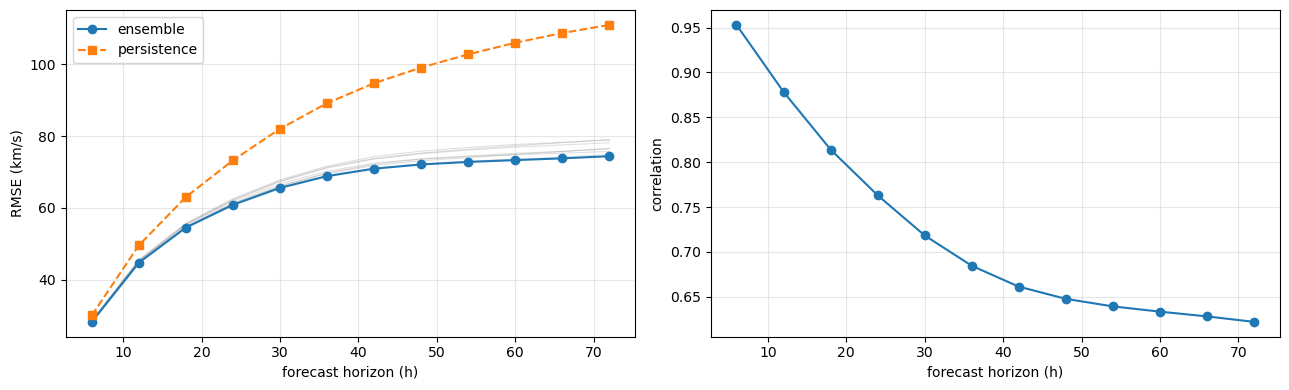

,horizon_h,rmse,mae,corr,persistence_rmse,gain
0,6,28.316576,18.560453,0.952960,30.133799,1.817224
1,12,44.770191,30.051345,0.878329,49.612603,4.842412
2,18,54.547297,37.822235,0.814055,63.040371,8.493075
3,24,60.873465,43.441105,0.763102,73.255360,12.381895
4,30,65.577387,47.333258,0.718325,82.029491,16.452104
5,36,68.855400,50.127663,0.684556,89.150125,20.294725
6,42,70.931416,52.079332,0.661308,94.699058,23.767642
7,48,72.101445,52.980261,0.647735,99.061863,26.960418
8,54,72.802597,53.645298,0.639310,102.730158,29.927561
9,60,73.311854,54.353709,0.633478,105.953524,32.641670


In [12]:
ensemble_val = apply_weights(member_val, ENSEMBLE_WEIGHTS)
ensemble_score, _ = official_rmse(val_targets, ensemble_val)
best_single = float(np.min(member_scores))

validation_metrics = metrics_by_horizon(val_targets, ensemble_val, val_persistence)
validation_metrics.to_csv(OUTPUT_DIR / "validation_metrics.csv", index=False)

print(f"ensemble RMSE     {ensemble_score:8.3f} km/s")
print(f"pooled RMSE       {pooled_rmse(val_targets, ensemble_val):8.3f} km/s")
print(f"best single       {best_single:8.3f} km/s")
print(f"ensemble gain     {best_single - ensemble_score:8.3f} km/s")
print(f"persistence       {persistence_score:8.3f} km/s")
print(f"improvement       {persistence_score - ensemble_score:8.3f} km/s "
      f"({(persistence_score - ensemble_score) / persistence_score:.1%})")

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
for index in range(len(member_states)):
    single = metrics_by_horizon(val_targets, member_val[index])
    axes[0].plot(single.horizon_h, single.rmse, alpha=0.25, linewidth=0.8, color="gray")
axes[0].plot(validation_metrics.horizon_h, validation_metrics.rmse, marker="o", label="ensemble")
axes[0].plot(validation_metrics.horizon_h, validation_metrics.persistence_rmse,
             marker="s", linestyle="--", label="persistence")
axes[0].set_xlabel("forecast horizon (h)"); axes[0].set_ylabel("RMSE (km/s)")
axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].plot(validation_metrics.horizon_h, validation_metrics["corr"], marker="o")
axes[1].set_xlabel("forecast horizon (h)"); axes[1].set_ylabel("correlation")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
validation_metrics

## 12. Test 추론 및 제출 파일 생성

In [13]:
ensemble_test = np.clip(apply_weights(member_test, ENSEMBLE_WEIGHTS), CLIP_LOW, CLIP_HIGH)
assert ensemble_test.shape == (len(test_inputs), 12)
assert np.isfinite(ensemble_test).all()

submission = pd.DataFrame(ensemble_test, columns=TARGET_COLUMNS)
submission.insert(0, "sample_id", test_inputs.sample_id.tolist())
submission.to_csv(SUBMISSION_DIR / "submission.csv", index=False)

torch.save({"member_state_dicts": member_states,
            "member_info": member_info,
            "ensemble_weights": ENSEMBLE_WEIGHTS.tolist(),
            "use_weighted": bool(USE_WEIGHTED),
            "val_rmse": ensemble_score,
            "ch_percentiles": list(CH_PERCENTILES),
            "ch_grid": list(CH_GRID),
            "disk_margin": DISK_MARGIN,
            "transit_speeds": list(TRANSIT_SPEEDS),
            "image_size": IMAGE_SIZE,
            "clip_low": CLIP_LOW, "clip_high": CLIP_HIGH,
            "initialization": "random_from_scratch"},
           SUBMISSION_DIR / "model.pth")

reloaded = torch.load(SUBMISSION_DIR / "model.pth", map_location="cpu", weights_only=False)
print(f"model.pth: {len(reloaded['member_state_dicts'])} members, "
      f"val {reloaded['val_rmse']:.3f}")
print("submission.csv:", submission.shape)
print(submission[TARGET_COLUMNS].describe().loc[["mean", "std", "min", "max"]].round(1))
submission.head()

model.pth: 7 members, val 63.357
submission.csv: (3868, 13)
      target_00  target_01  target_02  target_03  target_04  target_05  \
mean      407.5      408.2      409.5      411.3      413.0      414.9   
std        85.8       81.3       76.8       72.6       69.0       65.9   
min       260.7      268.1      279.8      288.3      293.3      297.2   
max       740.8      727.3      712.0      692.3      672.2      664.5   

      target_06  target_07  target_08  target_09  target_10  target_11  
mean      416.5      417.7      418.8      419.2      419.6      419.9  
std        64.1       62.4       61.1       60.3       59.7       58.9  
min       300.4      304.8      307.1      306.9      308.3      309.4  
max       662.5      655.6      654.0      655.2      653.9      651.6  


,sample_id,target_00,target_01,target_02,target_03,target_04,target_05,target_06,target_07,target_08,target_09,target_10,target_11
0,sample_07393cebc8e6882a,636.970245,624.380568,612.976234,600.722903,584.572600,569.508821,556.766613,540.277915,526.407294,517.272020,506.878334,496.024088
1,sample_640b9e2639db9b4f,381.530494,379.150002,378.481873,378.621593,381.550585,385.687138,387.554337,389.049125,388.628339,386.556295,385.227275,384.152614
2,sample_cd1159b14b325e4b,425.304830,417.729711,411.795713,405.516439,398.775301,392.682639,388.041012,383.860988,381.218849,380.813685,380.524147,381.123387
3,sample_cdb23a4bf60ec4df,380.184337,376.037236,372.208832,367.846927,363.904096,362.988289,360.645819,358.645153,356.123487,355.196695,355.270824,356.067235
4,sample_3713237d245e38bb,424.871997,444.205854,463.157938,471.140019,477.191834,480.439306,479.040525,475.244669,469.499031,466.378938,465.080057,459.500551


## 13. 제출 파일 점검

`submission/` 아래 `code.ipynb`, `model.pth`, `submission.csv` 세 파일이 필요하다.
`code.ipynb` 는 이 노트북을 저장한 뒤 해당 경로로 복사한다.

In [14]:
EXPECTED_TEST_ROWS = 3868

for name in ["code.ipynb", "model.pth", "submission.csv"]:
    path = SUBMISSION_DIR / name
    status = f"{path.stat().st_size / 1024 ** 2:8.2f} MiB" if path.exists() else "missing"
    print(f"  {name:16s} {status}")

check = pd.read_csv(SUBMISSION_DIR / "submission.csv")
print(f"\n  rows       {len(check):,} (expected {EXPECTED_TEST_ROWS:,})")
print(f"  columns    {check.columns.tolist() == ['sample_id'] + TARGET_COLUMNS}")
print(f"  nan        {int(check[TARGET_COLUMNS].isna().sum().sum())}")
print(f"  unique id  {check.sample_id.is_unique}")
print(f"  id match   {sorted(check.sample_id) == sorted(test_ids.sample_id)}")
print(f"  range      [{check[TARGET_COLUMNS].to_numpy().min():.1f}, "
      f"{check[TARGET_COLUMNS].to_numpy().max():.1f}] km/s")

extra = [p.name for p in SUBMISSION_DIR.iterdir()
         if p.name not in {"code.ipynb", "model.pth", "submission.csv"}]
if extra:
    print(f"\n  extra files: {extra}")

  code.ipynb       missing
  model.pth           11.09 MiB
  submission.csv       0.90 MiB

  rows       3,868 (expected 3,868)
  columns    True
  nan        0
  unique id  True
  id match   True
  range      [260.7, 740.8] km/s

  extra files: ['.ipynb_checkpoints']
